In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
engData = pd.read_csv('./data/eng_data.csv')

In [3]:
print(engData.head().to_markdown())

|    | Timestamp           |   TransactionID |   AccountID |   Amount | Merchant   | TransactionType   | Location    |   Year |   Quarter |   Month | Day_Of_Week   |   Day_Of_Month |   Day_Of_Year |   Hour |   Minute |
|---:|:--------------------|----------------:|------------:|---------:|:-----------|:------------------|:------------|-------:|----------:|--------:|:--------------|---------------:|--------------:|-------:|---------:|
|  0 | 2023-01-01 08:00:00 |            1127 |           4 | 95071.9  | H          | Purchase          | Tokyo       |   2023 |         1 |       1 | Sunday        |              1 |             1 |      8 |        0 |
|  1 | 2023-01-01 08:01:00 |            1639 |          10 | 15607.9  | H          | Purchase          | London      |   2023 |         1 |       1 | Sunday        |              1 |             1 |      8 |        1 |
|  2 | 2023-01-01 08:02:00 |             872 |           8 | 65092.3  | E          | Withdrawal        | London      |   202

In [4]:
print(engData[engData['TransactionType'] == 'Transfer'].head().to_markdown())
print(engData[engData['TransactionType'] == 'Transfer']['Merchant'].unique())

print(engData[engData['TransactionType'] == 'Withdrawal'].head().to_markdown())
print(engData[engData['TransactionType'] == 'Withdrawal']['Merchant'].unique())

print(engData[engData['TransactionType'] == 'Purchase'].head().to_markdown())
print(engData[engData['TransactionType'] == 'Purchase']['Merchant'].unique())


|    | Timestamp           |   TransactionID |   AccountID |   Amount | Merchant   | TransactionType   | Location      |   Year |   Quarter |   Month | Day_Of_Week   |   Day_Of_Month |   Day_Of_Year |   Hour |   Minute |
|---:|:--------------------|----------------:|------------:|---------:|:-----------|:------------------|:--------------|-------:|----------:|--------:|:--------------|---------------:|--------------:|-------:|---------:|
|  5 | 2023-01-01 08:05:00 |            1083 |          15 | 13958    | C          | Transfer          | London        |   2023 |         1 |       1 | Sunday        |              1 |             1 |      8 |        5 |
|  6 | 2023-01-01 08:06:00 |             832 |           9 |  4654.58 | C          | Transfer          | Tokyo         |   2023 |         1 |       1 | Sunday        |              1 |             1 |      8 |        6 |
|  8 | 2023-01-01 08:08:00 |             777 |          10 |  9776.23 | D          | Transfer          | London     

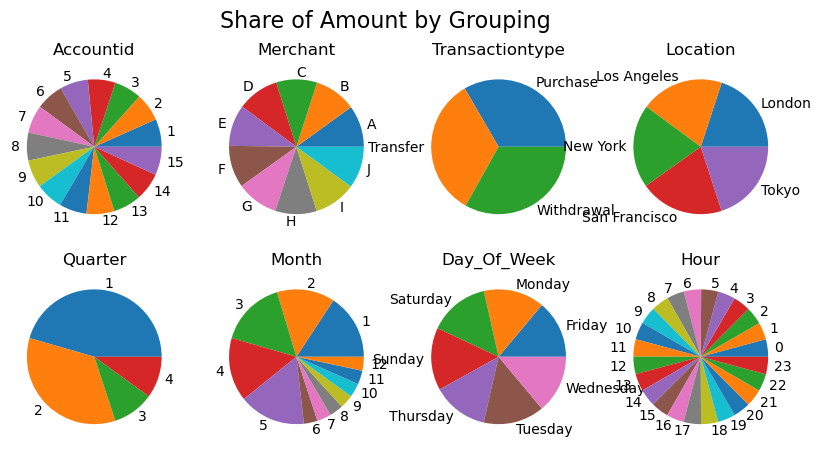

In [5]:
# Check for Balance across categories
fig, axs = plt.subplots(2, 4, figsize=(10, 5)) 
axs = axs.flatten()
for i, col in enumerate(['AccountID', 'Merchant','TransactionType','Location','Quarter','Month','Day_Of_Week', 'Hour']):
    grouped = engData.groupby(col)['Amount'].sum()
    grouped.plot(kind='pie', ax=axs[i])
    axs[i].set_ylabel('')
    axs[i].set_title(col.title())

fig.suptitle('Share of Amount by Grouping', fontsize=16)
plt.show()

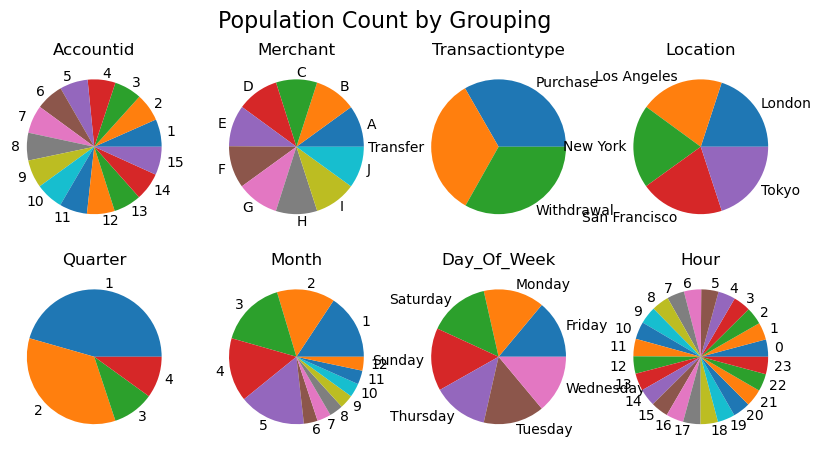

In [6]:
# Check for Balance across categories
fig, axs = plt.subplots(2, 4, figsize=(10, 5)) 
axs = axs.flatten()
for i, col in enumerate(['AccountID', 'Merchant','TransactionType','Location','Quarter','Month','Day_Of_Week', 'Hour']):
    grouped = engData.groupby(col)['Amount'].count()
    grouped.plot(kind='pie', ax=axs[i])
    axs[i].set_ylabel('')
    axs[i].set_title(col.title())

fig.suptitle('Population Count by Grouping', fontsize=16)
plt.show()